# <center>Student Performance Analysis 

## Project Question:
**What factors are associated with student academic performance?**

## Guiding Questions:
1. Does study time relate to final grades?
2. Does attendance affect performance?
3. Does previous academic performance predict final grades?
4. Are there differences between schools?
5. Does family background appear related to performance?
6. Which variables have the strongest relationship with final grade?

The steps this notebooks will follow are:
1. Data loading
2. Inspection
3. Cleaning
4. Exploratory data analysis
5. Visualizations
6. Conclusions and recommendations

In [1]:
# load the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
# load the mathematics csv
math_df = pd.read_csv("student-mat.csv", sep = ';') # the csv is not separated by a comma, but by a semicolon. specify to avoid problems
math_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# load the portuguese csv
port_df = pd.read_csv("student-por.csv", sep = ';')
port_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
# Open and read the txt file
with open('student.txt', 'r', encoding='utf-8') as file:
    content = file.read()

# Print the text to the VS Code terminal
print(content)


# Attributes for both student-mat.csv (Math course) and student-por.csv (Portuguese language course) datasets:
1 school - student's school (binary: "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira)
2 sex - student's sex (binary: "F" - female or "M" - male)
3 age - student's age (numeric: from 15 to 22)
4 address - student's home address type (binary: "U" - urban or "R" - rural)
5 famsize - family size (binary: "LE3" - less or equal to 3 or "GT3" - greater than 3)
6 Pstatus - parent's cohabitation status (binary: "T" - living together or "A" - apart)
7 Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
8 Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
9 Mjob - mother's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or 

### Miscellaneous Info
**Nominal data** - there's no inherent ranking between the data. eg:   
- Gender: male vs female, mother vs father  
- Eye color: Brown, Blue, Green  
- Marital status: Single, Married, Divorced  
- Blood type: A, B, AB, O  

**Ordinal data** - has categories where the order or ranking matters, but the mathematical distance between the categories is unknown or unequal. eg:    
- Customer satisfaction: Unsatisfied, Neutral, Satisfied
- Education level: High School, Bachelor's, Master's, PhD
- T-shirt size: Small, Medium, Large


## Data Inspection

In [5]:
print(f"Mathematics CSV Columns: \n{math_df.columns}")
print(f"Portuguese CSV Columns: \n{port_df.columns}")


Mathematics CSV Columns: 
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
Portuguese CSV Columns: 
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [6]:
print(math_df.shape)
print(port_df.shape)

(395, 33)
(649, 33)


In [7]:
# get a quick and comprehensive summary of the Maths DataFrame
print(math_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [8]:
# # get a quick and comprehensive summary of the Portuguese DataFrame
print(port_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [9]:
# identify missing values in percentage form - Maths
math_df.isnull().mean().sort_values()*100

school        0.0
G1            0.0
absences      0.0
health        0.0
Walc          0.0
Dalc          0.0
goout         0.0
freetime      0.0
famrel        0.0
romantic      0.0
internet      0.0
higher        0.0
nursery       0.0
activities    0.0
paid          0.0
G2            0.0
famsup        0.0
failures      0.0
studytime     0.0
traveltime    0.0
guardian      0.0
reason        0.0
Fjob          0.0
Mjob          0.0
Fedu          0.0
Medu          0.0
Pstatus       0.0
famsize       0.0
address       0.0
age           0.0
sex           0.0
schoolsup     0.0
G3            0.0
dtype: float64

In [10]:
# identify missing values in percentage form - Portuguese
port_df.isnull().mean().sort_values()*100

school        0.0
G1            0.0
absences      0.0
health        0.0
Walc          0.0
Dalc          0.0
goout         0.0
freetime      0.0
famrel        0.0
romantic      0.0
internet      0.0
higher        0.0
nursery       0.0
activities    0.0
paid          0.0
G2            0.0
famsup        0.0
failures      0.0
studytime     0.0
traveltime    0.0
guardian      0.0
reason        0.0
Fjob          0.0
Mjob          0.0
Fedu          0.0
Medu          0.0
Pstatus       0.0
famsize       0.0
address       0.0
age           0.0
sex           0.0
schoolsup     0.0
G3            0.0
dtype: float64

In [11]:
# identify duplicates for the Maths column
math_df.duplicated().sort_values(ascending=False)

0      False
271    False
269    False
268    False
267    False
       ...  
129    False
128    False
127    False
126    False
394    False
Length: 395, dtype: bool

In [12]:
# identify duplicates for the Portuguese column
port_df.duplicated().sort_values(ascending=False)

0      False
446    False
428    False
429    False
430    False
       ...  
218    False
219    False
220    False
221    False
648    False
Length: 649, dtype: bool

## Data Cleaning

In [13]:
# rename G3 to final grade for ease of understanding
math_df = math_df.rename(columns={'G3': 'final_grade'})
port_df = port_df.rename(columns={'G3': 'final_grade'})

# rename G2 to second_grade
math_df = math_df.rename(columns = {'G2': 'second_grade'})
port_df = port_df.rename(columns = {'G2': 'second_grade'})

# rename G1 to first_grade
math_df = math_df.rename(columns = {'G1': 'first_grade'})
port_df = port_df.rename(columns = {'G1': 'first_grade'})

math_df.info()
port_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   school        395 non-null    object
 1   sex           395 non-null    object
 2   age           395 non-null    int64 
 3   address       395 non-null    object
 4   famsize       395 non-null    object
 5   Pstatus       395 non-null    object
 6   Medu          395 non-null    int64 
 7   Fedu          395 non-null    int64 
 8   Mjob          395 non-null    object
 9   Fjob          395 non-null    object
 10  reason        395 non-null    object
 11  guardian      395 non-null    object
 12  traveltime    395 non-null    int64 
 13  studytime     395 non-null    int64 
 14  failures      395 non-null    int64 
 15  schoolsup     395 non-null    object
 16  famsup        395 non-null    object
 17  paid          395 non-null    object
 18  activities    395 non-null    object
 19  nursery 

## Exploratory Data Analysis
### 1. Does study time relate to final grades?

In [14]:
# for the Maths subject
# final grade (numeric: from 0 to 20, output target)
# studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)

print(math_df['final_grade'].value_counts().sort_index())
print(math_df['studytime'].value_counts())


final_grade
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64
studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64


In [15]:
# group final grade by studytime
print("\nMath Final Grade by Studytime Grouping:")
display(math_df.groupby('final_grade')['studytime'].mean())

print("\nPortuguese Final Grade by Studytime Grouping:")
display(port_df.groupby('final_grade')['studytime'].mean())


Math Final Grade by Studytime Grouping:


final_grade
0     1.973684
4     2.000000
5     1.428571
6     1.933333
7     1.888889
8     1.937500
9     2.071429
10    1.946429
11    2.148936
12    1.935484
13    1.935484
14    2.296296
15    2.151515
16    2.125000
17    2.500000
18    2.083333
19    2.000000
20    4.000000
Name: studytime, dtype: float64


Portuguese Final Grade by Studytime Grouping:


final_grade
0     1.466667
1     2.000000
5     1.000000
6     2.000000
7     1.300000
8     1.800000
9     1.542857
10    1.762887
11    1.778846
12    1.986111
13    2.085366
14    2.063492
15    2.204082
16    2.055556
17    2.275862
18    2.533333
19    3.000000
Name: studytime, dtype: float64

In [16]:
# group final grade by studytime
print("\nMath Final Grade by Studytime Grouping:")
display(math_df.groupby('studytime')['final_grade'].mean())

print("\nPortuguese Final Grade by Studytime Grouping:")
display(port_df.groupby('studytime')['final_grade'].mean())


Math Final Grade by Studytime Grouping:


studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: final_grade, dtype: float64


Portuguese Final Grade by Studytime Grouping:


studytime
1    10.844340
2    12.091803
3    13.226804
4    13.057143
Name: final_grade, dtype: float64

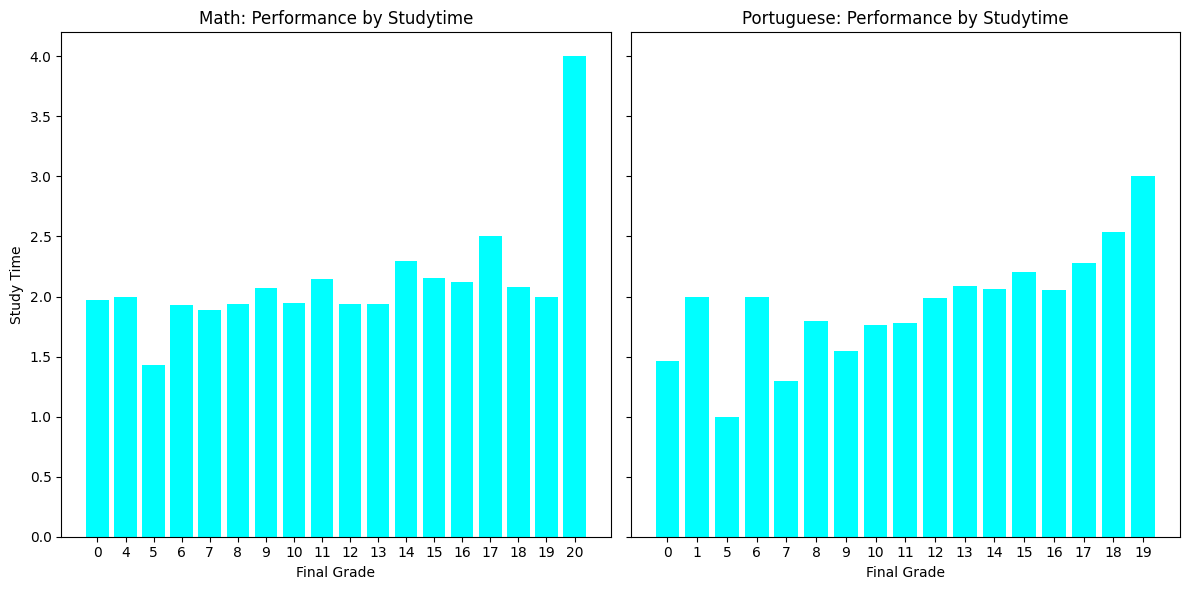

In [17]:
# create barplots for final grade by studytime using subplots code for both Maths and Portuguese

# Grouped data
studytime_math = math_df.groupby('final_grade')['studytime'].mean()
studytime_port = port_df.groupby('final_grade')['studytime'].mean()

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot math_df
axes[0].bar(
    studytime_math.index.astype(str),
    studytime_math.to_numpy(),
    color = 'cyan'
)
axes[0].set_xlabel('Final Grade')
axes[0].set_ylabel('Study Time')
axes[0].set_title('Math: Performance by Studytime')

# Plot port_df
axes[1].bar(
    studytime_port.index.astype(str),
    studytime_port.to_numpy(),
    color = 'cyan'

)
axes[1].set_xlabel('Final Grade')
axes[1].set_title('Portuguese: Performance by Studytime')

# Adjust layout
plt.tight_layout()
plt.show()


Variable - Studytime - weekly study time   
    (numeric: 1 - <2 hours,   
    2 - 2 to 5 hours,   
    3 - 5 to 10 hours, or   
    4 - >10 hours)  

**Interpretation:**  
There is a visible relationship between study time and the final grade the student got. This is especially pronounced for grade 20 in Maths and grade 19 for Portuguese, which are the highest marks obtained in both subjects. These students dedicated 5 to 10 hours or greater than 10 hours in studytime.

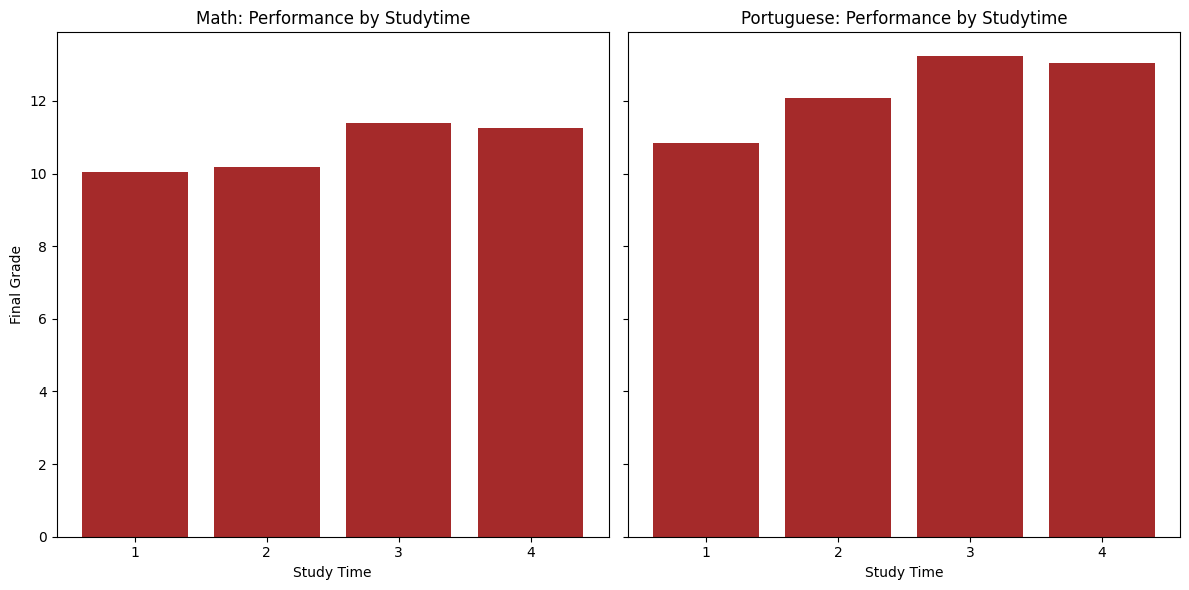

In [18]:
# create barplots for final grade by studytime using subplots code for both Maths and Portuguese

# Grouped data
studytime_math = math_df.groupby('studytime')['final_grade'].mean()
studytime_port = port_df.groupby('studytime')['final_grade'].mean()

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot math_df
axes[0].bar(
    studytime_math.index.astype(str),
    studytime_math.to_numpy(),
    color = 'brown'
)
axes[0].set_xlabel('Study Time')
axes[0].set_ylabel('Final Grade')
axes[0].set_title('Math: Performance by Studytime')

# Plot port_df
axes[1].bar(
    studytime_port.index.astype(str),
    studytime_port.to_numpy(),
    color = 'brown'
)
axes[1].set_xlabel('Study Time')
axes[1].set_title('Portuguese: Performance by Studytime')

# Adjust layout
plt.tight_layout()
plt.show()

# final grade (numeric: from 0 to 20, output target)
# studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)


Variable - Studytime - weekly study time   
    (numeric: 1 - <2 hours,   
    2 - 2 to 5 hours,   
    3 - 5 to 10 hours, or   
    4 - >10 hours)  

**Interpretation:**  
There is a visible relationship between study time and the final grade the student got. This is especially pronounced for grade 20 in Maths and grade 19 for Portuguese, which are the highest marks obtained in both subjects. These students dedicated 5 to 10 hours or greater than 10 hours in studytime.

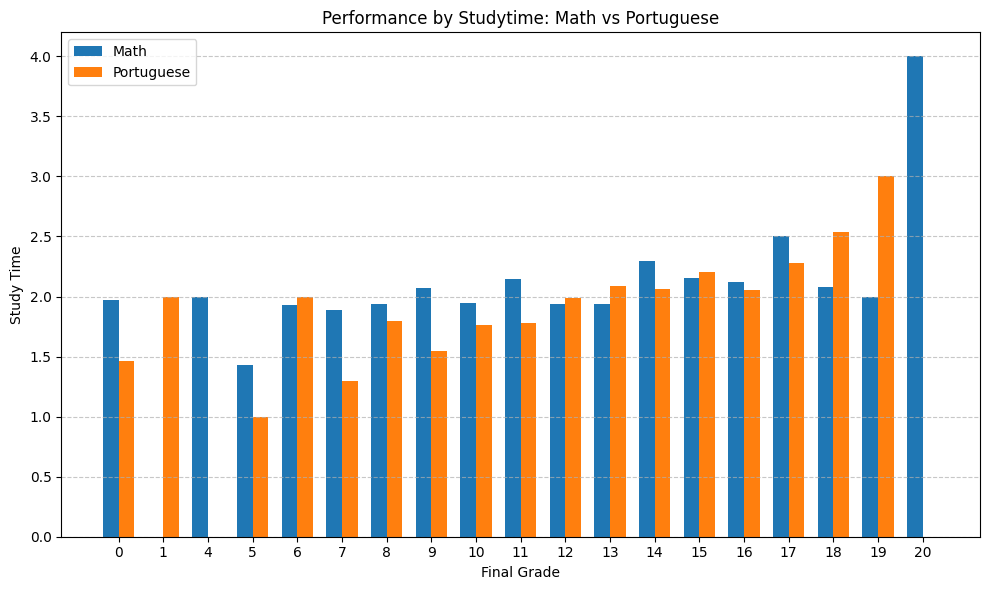

In [19]:
# simplified code for the above where they are stacked next to each other in the same plot

# Grouped data
studytime_math = math_df.groupby('final_grade')['studytime'].mean()
studytime_port = port_df.groupby('final_grade')['studytime'].mean()

# Ensure both have the same index order
grades = sorted(set(studytime_math.index) | set(studytime_port.index))

# Convert to arrays aligned by grade
math_values = [studytime_math.get(g, 0) for g in grades]
port_values = [studytime_port.get(g, 0) for g in grades]

# X positions
x = np.arange(len(grades))
width = 0.35  # width of each bar

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, math_values, width, label='Math')
plt.bar(x + width/2, port_values, width, label='Portuguese')

plt.xlabel('Final Grade')
plt.ylabel('Study Time')
plt.title('Performance by Studytime: Math vs Portuguese')
plt.xticks(x, [str(g) for g in grades])
plt.grid(axis='y', linestyle='--', alpha=0.7) # Horizontal gridlines
plt.legend()

plt.tight_layout()
plt.show()


Variable - Studytime - weekly study time   
    (numeric: 1 - <2 hours,   
    2 - 2 to 5 hours,   
    3 - 5 to 10 hours, or   
    4 - >10 hours)  

**Interpretation:**  
There is a visible relationship between study time and the final grade the student got. This is especially pronounced for grade 20 in Maths and grade 19 for Portuguese, which are the highest marks obtained in both subjects. These students dedicated 5 to 10 hours or greater than 10 hours in studytime.

### 2. Does attendance affect performance?

In [20]:
# group final grade by number of absences
print("Number of Absences for Maths:")
display(math_df.groupby('final_grade')['absences'].median())

print("Number of Absences for Portuguese:")
display(port_df.groupby('final_grade')['absences'].median())

Number of Absences for Maths:


final_grade
0      0.0
4     22.0
5     14.0
6      6.0
7      5.0
8      6.5
9      6.5
10     4.0
11     4.0
12     2.0
13     6.0
14     4.0
15     2.0
16     2.0
17     1.0
18     3.0
19     5.0
20     4.0
Name: absences, dtype: float64

Number of Absences for Portuguese:


final_grade
0      0.0
1      0.0
5     12.0
6      4.0
7      5.5
8      4.0
9      4.0
10     4.0
11     4.0
12     2.0
13     1.5
14     2.0
15     2.0
16     0.5
17     2.0
18     0.0
19     2.0
Name: absences, dtype: float64

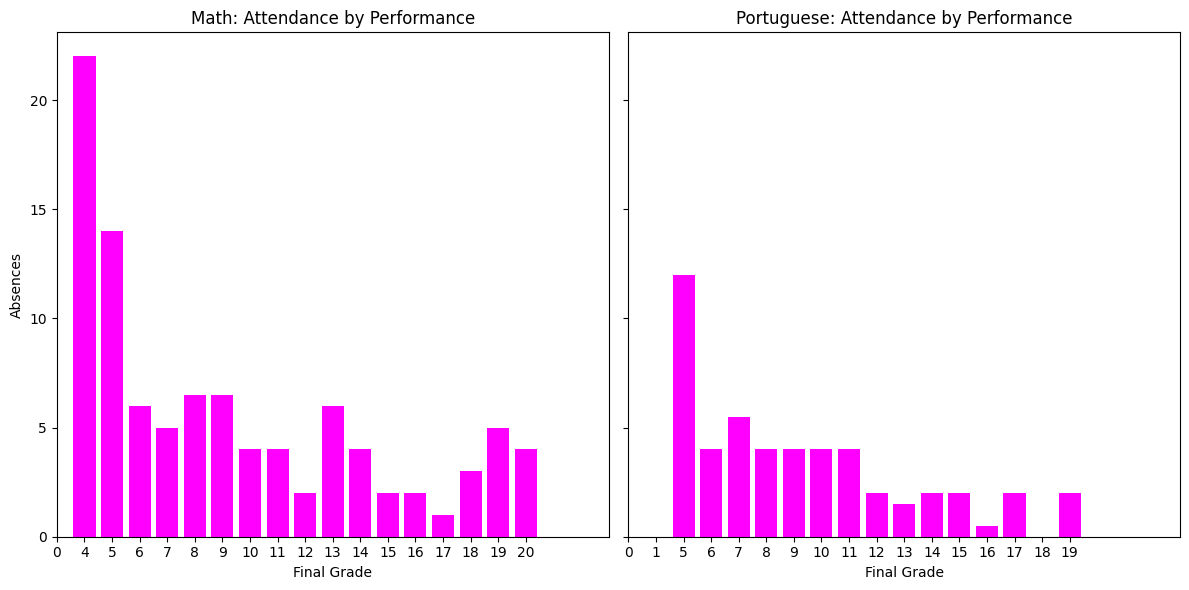

In [21]:
# create barplots for final grade by studytime using subplots code for both Maths and Portuguese

# Grouped data
math_attendance_by_performance = math_df.groupby('final_grade')['absences'].median()
port_attendance_by_performance = port_df.groupby('final_grade')['absences'].median()

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot math_df
axes[0].bar(
    math_attendance_by_performance.index.astype(str),
    math_attendance_by_performance.to_numpy(),
    color = 'magenta'
)
axes[0].set_xlim(0, 20)
axes[0].set_xlabel('Final Grade')
axes[0].set_ylabel('Absences')
axes[0].set_title('Math: Attendance by Performance')

# Plot port_df
axes[1].bar(
    port_attendance_by_performance.index.astype(str),
    port_attendance_by_performance.to_numpy(),
    color = 'magenta'
)
axes[1].set_xlim(0, 20)
axes[1].set_xlabel('Final Grade')
axes[1].set_title('Portuguese: Attendance by Performance')

# Adjust layout
plt.tight_layout()
plt.show()


**Interpretation: Students with high number of absences have lower grades in both Maths and Portuguese. There is a definite trend downwards in the graphs as lower absences correspond with higher grades**

### 3. Does previous academic performance predict final grades?

In [22]:
# conduct correlation test to see how the grades are related
display(math_df[['first_grade', 'second_grade', 'final_grade']].corr())
display(port_df[['first_grade', 'second_grade', 'final_grade']].corr())

,first_grade,second_grade,final_grade
first_grade,1.000000,0.852118,0.801468
second_grade,0.852118,1.000000,0.904868
final_grade,0.801468,0.904868,1.000000


,first_grade,second_grade,final_grade
first_grade,1.000000,0.864982,0.826387
second_grade,0.864982,1.000000,0.918548
final_grade,0.826387,0.918548,1.000000


**Interpretation: There is a strong positive correlation with first period grade and final grade (0.8 Maths, 0.82 Portuguese), similarly, there is a strong positive relationship between second period grade and final (0.9 Maths, 0.91 Portuguese). This means that higher first period and second period grades correspond to higher final grade values.**

#### Second Period Grade
#### Maths

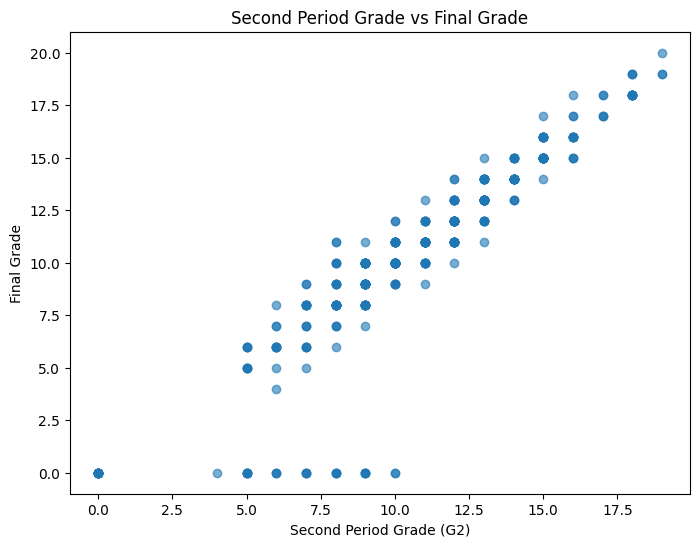

In [23]:
# using matplotlib
plt.figure(figsize=(8, 6))

plt.scatter(math_df['second_grade'], math_df['final_grade'], alpha=0.6)

plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade')
plt.title('Second Period Grade vs Final Grade')

plt.show()

#### Portuguese

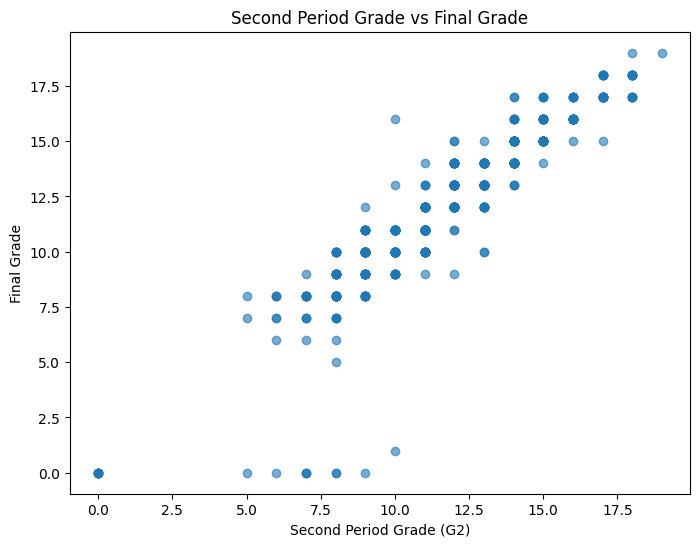

In [24]:
# using matplotlib
plt.figure(figsize=(8, 6))

plt.scatter(port_df['second_grade'], port_df['final_grade'], alpha=0.6)

plt.xlabel('Second Period Grade (G2)')
plt.ylabel('Final Grade')
plt.title('Second Period Grade vs Final Grade')

plt.show()

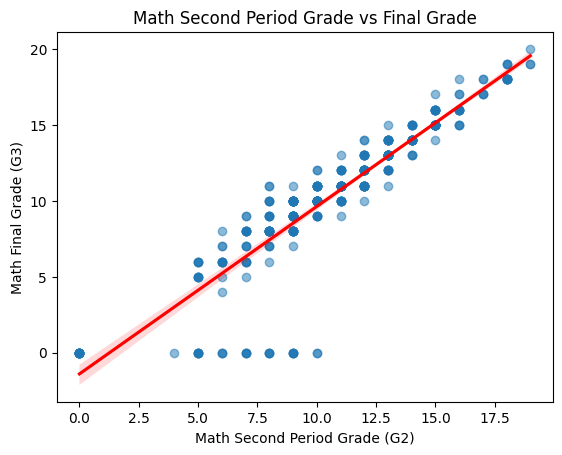

In [25]:
# putting regression lines on the Maths plot - using seaborn
sns.regplot(
    data=math_df,
    x='second_grade',
    y='final_grade',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.xlabel('Math Second Period Grade (G2)')
plt.ylabel('Math Final Grade (G3)')
plt.title('Math Second Period Grade vs Final Grade')

plt.show()

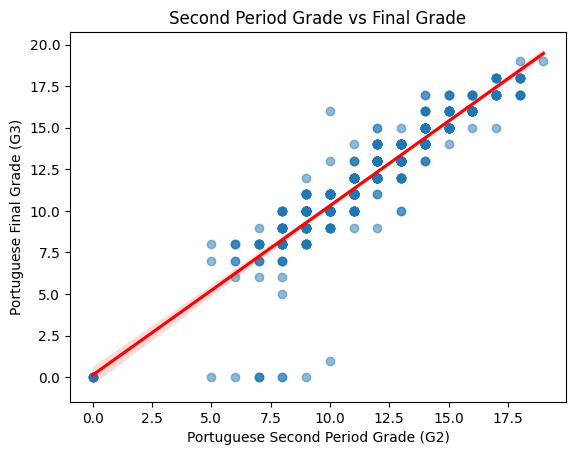

In [26]:
# putting regression lines on the portuguese plot
sns.regplot(
    data=port_df,
    x='second_grade',
    y='final_grade',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.xlabel('Portuguese Second Period Grade (G2)')
plt.ylabel('Portuguese Final Grade (G3)')
plt.title('Second Period Grade vs Final Grade')

plt.show()

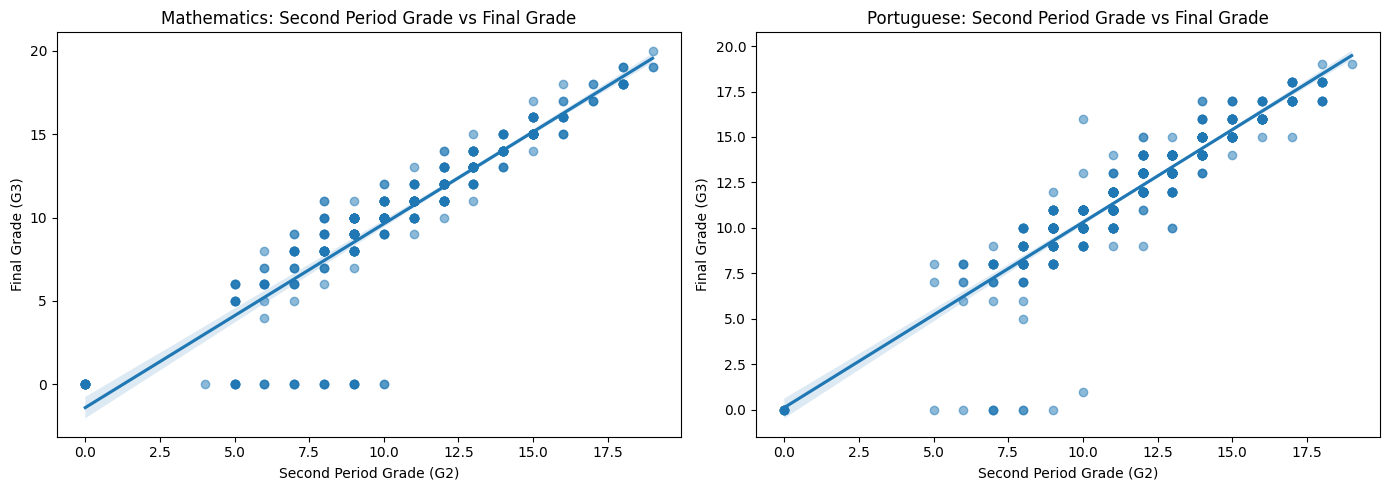

In [27]:
# using subplots for the above codes - both Maths and Portuguese 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=math_df,
    x='second_grade',
    y='final_grade',
    ax=axes[0],
    scatter_kws={'alpha': 0.5}
)

axes[0].set_title('Mathematics: Second Period Grade vs Final Grade')
axes[0].set_xlabel('Second Period Grade (G2)')
axes[0].set_ylabel('Final Grade (G3)')


sns.regplot(
    data=port_df,
    x='second_grade',
    y='final_grade',
    ax=axes[1],
    scatter_kws={'alpha': 0.5}
)

axes[1].set_title('Portuguese: Second Period Grade vs Final Grade')
axes[1].set_xlabel('Second Period Grade (G2)')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.show()

**Adding a regression line to a scatter plot makes the relationship between two variables clearer, quantifies the strength of correlation, and allows predictions of outcomes based on observed trends. It transforms a cloud of points into a readable model that highlights patterns, direction, and reliability.**

- Correlation: Strong positive correlation between second period grade and final grade.

- Trend: Students with higher second-period grades tend to maintain or improve in the final grade.

- Regression Line: Steep slope, narrow confidence interval → strong predictive power.

#### First Period Grade
#### Maths

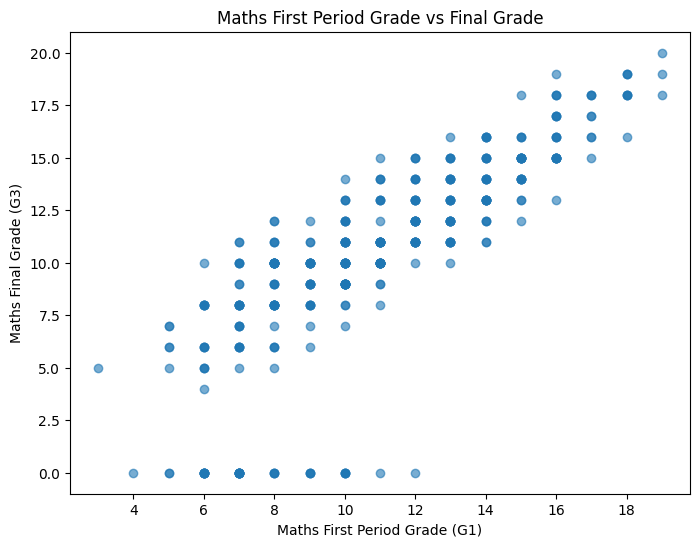

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(math_df['first_grade'], math_df['final_grade'], alpha=0.6)

plt.xlabel('Maths First Period Grade (G1)')
plt.ylabel('Maths Final Grade (G3)')
plt.title('Maths First Period Grade vs Final Grade')

plt.show()

#### Portuguese

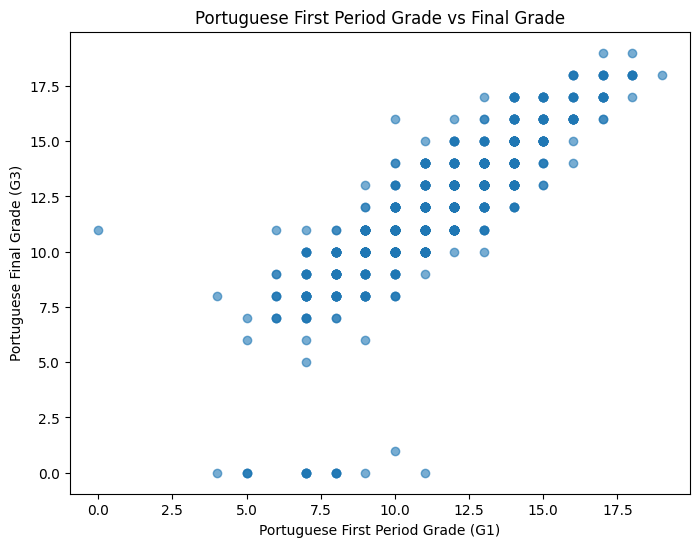

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(port_df['first_grade'], port_df['final_grade'], alpha=0.6)

plt.xlabel('Portuguese First Period Grade (G1)')
plt.ylabel('Portuguese Final Grade (G3)')
plt.title('Portuguese First Period Grade vs Final Grade')

plt.show()

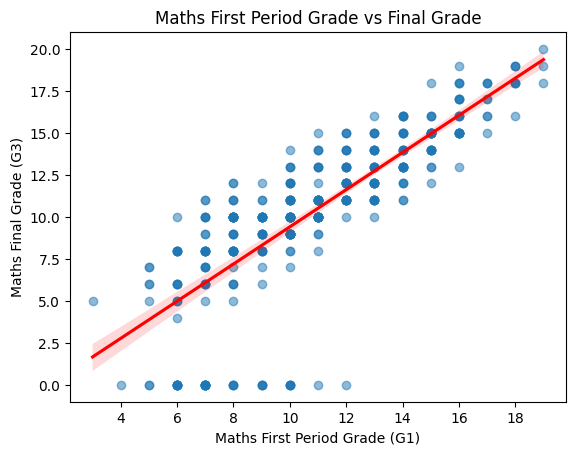

In [30]:
# putting regression lines on the plots
sns.regplot(
    data=math_df,
    x='first_grade',
    y='final_grade',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.xlabel('Maths First Period Grade (G1)')
plt.ylabel('Maths Final Grade (G3)')
plt.title('Maths First Period Grade vs Final Grade')

plt.show()

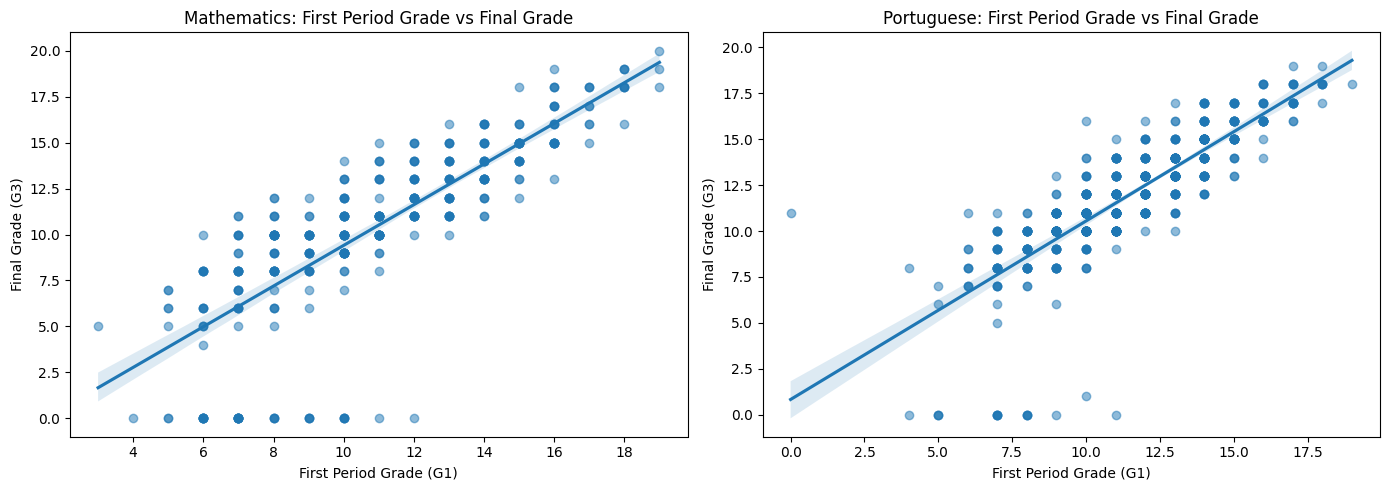

In [31]:
# using subplots for the above codes - both Maths and Portuguese 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=math_df,
    x='first_grade',
    y='final_grade',
    ax=axes[0],
    scatter_kws={'alpha': 0.5}
)

axes[0].set_title('Mathematics: First Period Grade vs Final Grade')
axes[0].set_xlabel('First Period Grade (G1)')
axes[0].set_ylabel('Final Grade (G3)')


sns.regplot(
    data=port_df,
    x='first_grade',
    y='final_grade',
    ax=axes[1],
    scatter_kws={'alpha': 0.5}
)

axes[1].set_title('Portuguese: First Period Grade vs Final Grade')
axes[1].set_xlabel('First Period Grade (G1)')
axes[1].set_ylabel('Final Grade (G3)')

plt.tight_layout()
plt.show()

- Correlation: Strong positive correlation between second period grade and final grade.

- Trend: Students with higher second-period grades tend to maintain or improve in the final grade.

- Regression Line: Steep slope, narrow confidence interval → strong predictive power.

### 4. Are there differences between schools?

In [32]:
# "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira
print("School count for the Maths students:")
display(math_df['school'].value_counts())

print("School count for the Maths students:")
display(port_df['school'].value_counts())

School count for the Maths students:


school
GP    349
MS     46
Name: count, dtype: int64

School count for the Maths students:


school
GP    423
MS    226
Name: count, dtype: int64

In [ ]:
# group the students by school, then calculate the average final grade for each school
print("Average Maths performance between the schools:")
display(math_df.groupby('school')['final_grade'].mean()) 

print("Average Portuguese performance between the schools:")
display(port_df.groupby('school')['final_grade'].mean())


Maths performance between the schools:


school
GP    10.489971
MS     9.847826
Name: final_grade, dtype: float64

Portuguese performance between the schools:


school
GP    12.576832
MS    10.650442
Name: final_grade, dtype: float64

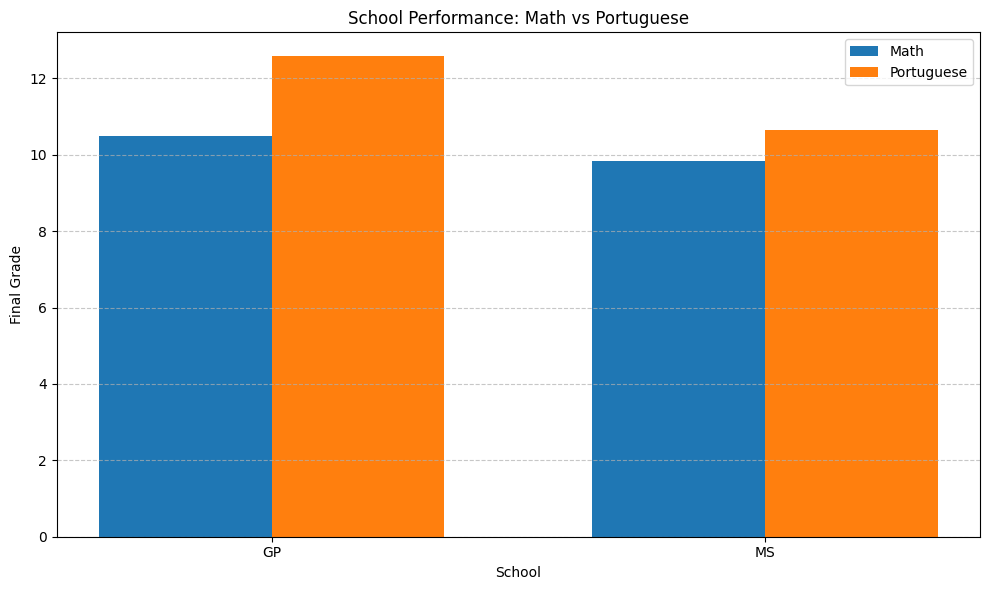

In [34]:
# code where they are grouped side by side in the same plot

# Grouped data
school_math = math_df.groupby('school')['final_grade'].mean()
school_port = port_df.groupby('school')['final_grade'].mean()

# Ensure both have the same index order
schools = sorted(set(school_math.index) | set(school_port.index))

# Convert to arrays aligned by grade
math_values = [school_math.get(s, 0) for s in schools]
port_values = [school_port.get(s, 0) for s in schools]

# X positions
x = np.arange(len(schools))
width = 0.35  # width of each bar

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, math_values, width, label='Math')
plt.bar(x + width/2, port_values, width, label='Portuguese')

plt.xlabel('School')
plt.ylabel('Final Grade')
plt.title('School Performance: Math vs Portuguese')
plt.xticks(x, schools)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Horizontal gridlines
plt.legend()

plt.tight_layout()
plt.show()


- "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira

**Interpretation: Gabriel Pereira outperformed Mousinho da Silveira in both Portguese and Maths in final grade performance**

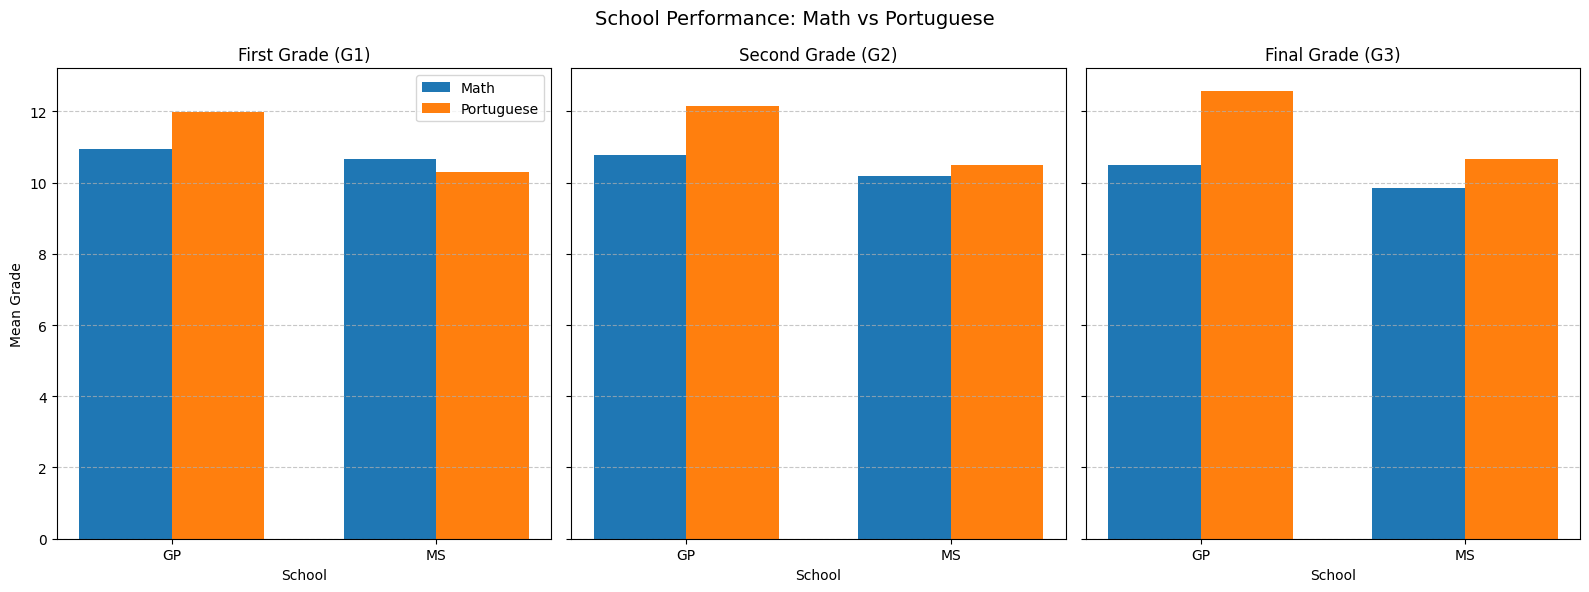

In [35]:
# School performance comparison: G1, G2 and G3
# Math vs Portuguese

# Calculate mean grades by school
math_g1 = math_df.groupby('school')['first_grade'].mean()
port_g1 = port_df.groupby('school')['first_grade'].mean()

math_g2 = math_df.groupby('school')['second_grade'].mean()
port_g2 = port_df.groupby('school')['second_grade'].mean()

math_g3 = math_df.groupby('school')['final_grade'].mean()
port_g3 = port_df.groupby('school')['final_grade'].mean()

# Ensure both datasets have the same school order
schools = sorted(set(math_df['school']) | set(port_df['school']))

# Create 1 row × 3 columns
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

# X positions
x = np.arange(len(schools))
width = 0.35

# --------------------
# First Grade (G1)
# --------------------

math_values = [math_g1.get(s, 0) for s in schools]
port_values = [port_g1.get(s, 0) for s in schools]

axes[0].bar(x - width/2, math_values, width, label='Math')
axes[0].bar(x + width/2, port_values, width, label='Portuguese')

axes[0].set_title('First Grade (G1)')
axes[0].set_xlabel('School')
axes[0].set_xticks(x)
axes[0].set_xticklabels(schools)
axes[0].set_ylabel('Mean Grade')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)


# --------------------
# Second Grade (G2)
# --------------------

math_values = [math_g2.get(s, 0) for s in schools]
port_values = [port_g2.get(s, 0) for s in schools]

axes[1].bar(x - width/2, math_values, width, label='Math')
axes[1].bar(x + width/2, port_values, width, label='Portuguese')

axes[1].set_title('Second Grade (G2)')
axes[1].set_xlabel('School')
axes[1].set_xticks(x)
axes[1].set_xticklabels(schools)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)


# --------------------
# Final Grade (G3)
# --------------------

math_values = [math_g3.get(s, 0) for s in schools]
port_values = [port_g3.get(s, 0) for s in schools]

axes[2].bar(x - width/2, math_values, width, label='Math')
axes[2].bar(x + width/2, port_values, width, label='Portuguese')

axes[2].set_title('Final Grade (G3)')
axes[2].set_xlabel('School')
axes[2].set_xticks(x)
axes[2].set_xticklabels(schools)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)


# Overall title
fig.suptitle('School Performance: Math vs Portuguese', fontsize=14)

# One shared legend
axes[0].legend()

plt.tight_layout()
plt.show()

- "GP" - Gabriel Pereira or "MS" - Mousinho da Silveira

**Interpretation: Gabriel Pereira outperformed Mousinho da Silveira in both Portguese and Maths in all grade examinations**

**Do mean final grades differ between the two schools, and is the pattern consistent across subjects?**

Then use a boxplot separately to investigate whether the distribution of grades differs even when the means are close.

So the analysis should have:

- Figure 1: Mean final grade by school — Maths vs Portuguese
- Figure 2: Final-grade distribution by school — Maths
- Figure 3: Final-grade distribution by school — Portuguese

### 5. Does family background appear related to performance?

In [36]:
math_df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'first_grade', 'second_grade',
       'final_grade'],
      dtype='object')

In [ ]:
# Parental education
# Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
# Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
print("\nMaths Parental Education:")
display(math_df.groupby('Medu')['final_grade'].mean())
display(math_df.groupby('Fedu')['final_grade'].mean())

print("\nPortuguese Parental Education:")
display(port_df.groupby('Medu')['final_grade'].mean())
display(port_df.groupby('Fedu')['final_grade'].mean())


Maths Parental Education:


Medu
0    13.000000
1     8.677966
2     9.728155
3    10.303030
4    11.763359
Name: final_grade, dtype: float64

Fedu
0    13.000000
1     9.158537
2    10.260870
3    10.660000
4    11.364583
Name: final_grade, dtype: float64


Portuguese Parental Education:


Medu
0    11.666667
1    10.797203
2    11.661290
3    11.920863
4    13.068571
Name: final_grade, dtype: float64

Fedu
0    12.142857
1    10.936782
2    11.784689
3    12.381679
4    12.921875
Name: final_grade, dtype: float64

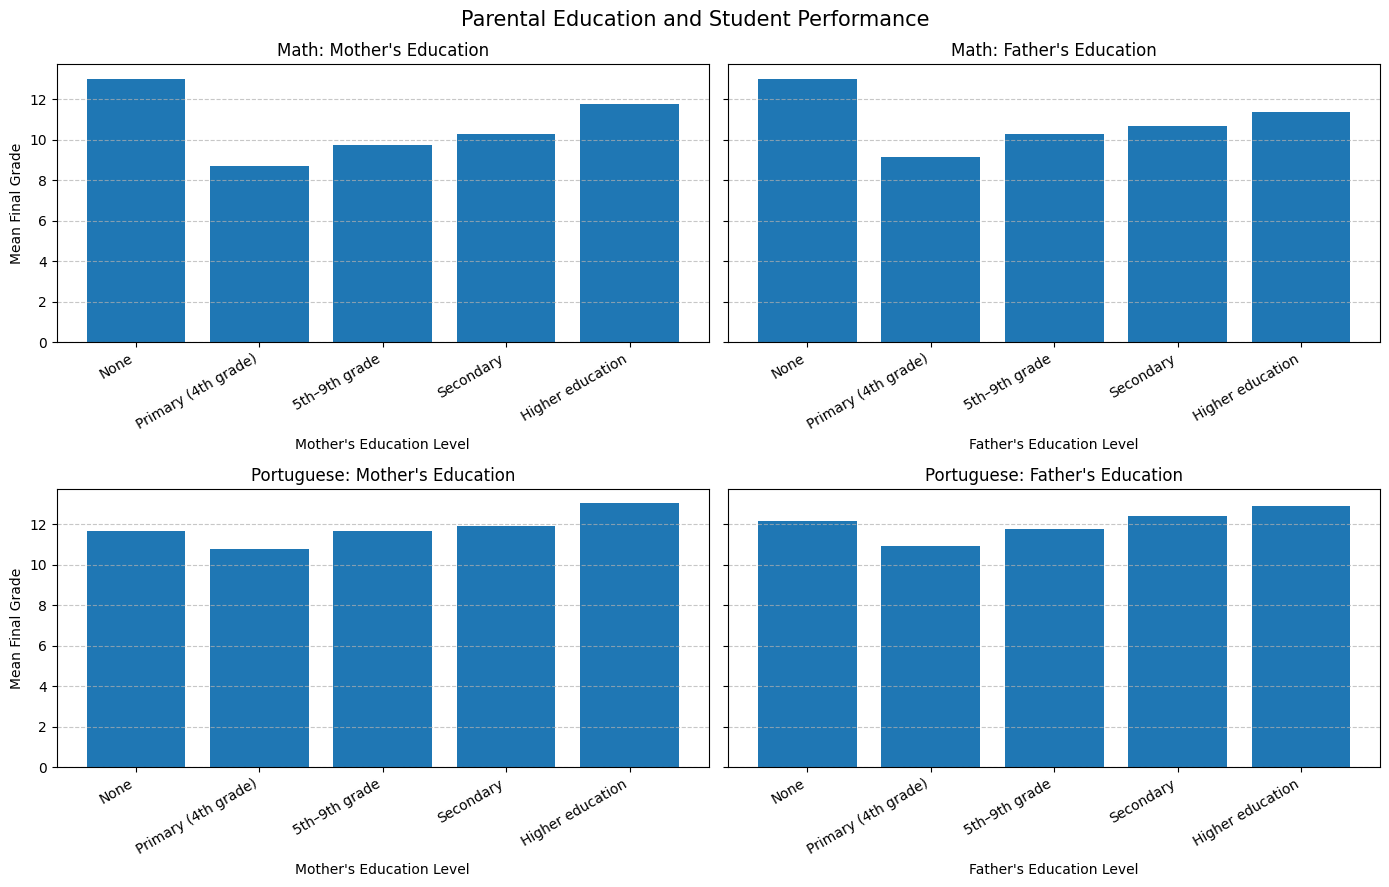

In [47]:
# Family background and academic performance
# Parental education vs final grade

# Grouped data
math_medu = math_df.groupby('Medu')['final_grade'].mean()
math_fedu = math_df.groupby('Fedu')['final_grade'].mean()

port_medu = port_df.groupby('Medu')['final_grade'].mean()
port_fedu = port_df.groupby('Fedu')['final_grade'].mean()


# Meaningful labels for education levels
education_labels = [
    'None',
    'Primary (4th grade)',
    '5th–9th grade',
    'Secondary',
    'Higher education'
]

education_codes = [0, 1, 2, 3, 4]


# Create 2 × 2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)


# -----------------------------
# Math — Mother's Education
# -----------------------------
axes[0, 0].bar(
    math_medu.index,
    math_medu.values
)

axes[0, 0].set_title("Math: Mother's Education")
axes[0, 0].set_xlabel("Mother's Education Level")
axes[0, 0].set_ylabel("Mean Final Grade")
axes[0, 0].set_xticks(education_codes)
axes[0, 0].set_xticklabels(education_labels, rotation=30, ha='right')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)


# -----------------------------
# Math — Father's Education
# -----------------------------
axes[0, 1].bar(
    math_fedu.index,
    math_fedu.values
)

axes[0, 1].set_title("Math: Father's Education")
axes[0, 1].set_xlabel("Father's Education Level")
axes[0, 1].set_xticks(education_codes)
axes[0, 1].set_xticklabels(education_labels, rotation=30, ha='right')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)


# -----------------------------
# Portuguese — Mother's Education
# -----------------------------
axes[1, 0].bar(
    port_medu.index,
    port_medu.values
)

axes[1, 0].set_title("Portuguese: Mother's Education")
axes[1, 0].set_xlabel("Mother's Education Level")
axes[1, 0].set_ylabel("Mean Final Grade")
axes[1, 0].set_xticks(education_codes)
axes[1, 0].set_xticklabels(education_labels, rotation=30, ha='right')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)


# -----------------------------
# Portuguese — Father's Education
# -----------------------------
axes[1, 1].bar(
    port_fedu.index,
    port_fedu.values
)

axes[1, 1].set_title("Portuguese: Father's Education")
axes[1, 1].set_xlabel("Father's Education Level")
axes[1, 1].set_xticks(education_codes)
axes[1, 1].set_xticklabels(education_labels, rotation=30, ha='right')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)


# Overall title
fig.suptitle(
    'Parental Education and Student Performance',
    fontsize=15
)

plt.tight_layout()
plt.show()

In [ ]:
# Parental occupation
# Mjob - mother's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or "other")
# Fjob - father's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or "other")
print("Maths Parental Occupation:")
display(math_df.groupby('Mjob')['final_grade'].mean())
display(math_df.groupby('Fjob')['final_grade'].mean())

print("Portuguese Parental Occupation:")
display(port_df.groupby('Mjob')['final_grade'].mean())
display(port_df.groupby('Fjob')['final_grade'].mean())

Maths Parental Occupation:


Mjob
at_home      9.152542
health      12.147059
other        9.822695
services    11.019417
teacher     11.051724
Name: final_grade, dtype: float64

Fjob
at_home     10.150000
health      11.611111
other       10.193548
services    10.297297
teacher     11.965517
Name: final_grade, dtype: float64

Portuguese Parental Occupation:


Mjob
at_home     11.044444
health      13.062500
other       11.670543
services    12.147059
teacher     13.138889
Name: final_grade, dtype: float64

Fjob
at_home     11.428571
health      12.565217
other       11.891008
services    11.629834
teacher     13.583333
Name: final_grade, dtype: float64

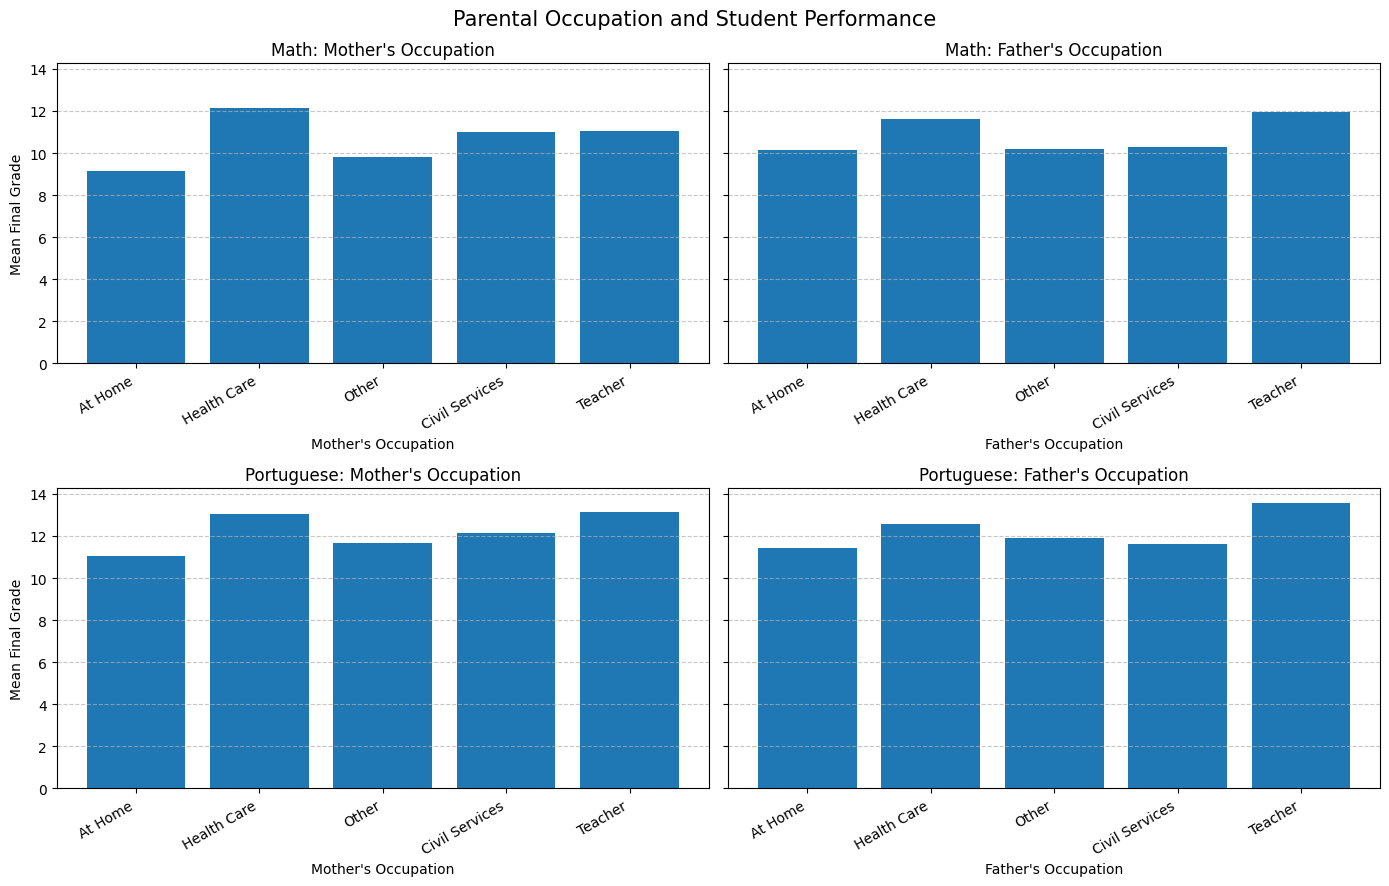

In [48]:
# Parental occupation and academic performance

# Grouped data
math_mjob = math_df.groupby('Mjob')['final_grade'].mean()
math_fjob = math_df.groupby('Fjob')['final_grade'].mean()

port_mjob = port_df.groupby('Mjob')['final_grade'].mean()
port_fjob = port_df.groupby('Fjob')['final_grade'].mean()


# Meaningful labels for occupation categories
occupation_labels = {
    'teacher': 'Teacher',
    'health': 'Health Care',
    'services': 'Civil Services',
    'at_home': 'At Home',
    'other': 'Other'
}


# Create 2 × 2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)


# -----------------------------
# Math — Mother's Occupation
# -----------------------------
axes[0, 0].bar(
    math_mjob.index,
    math_mjob.values
)

axes[0, 0].set_title("Math: Mother's Occupation")
axes[0, 0].set_xlabel("Mother's Occupation")
axes[0, 0].set_ylabel("Mean Final Grade")

axes[0, 0].set_xticks(math_mjob.index)
axes[0, 0].set_xticklabels(
    [occupation_labels[x] for x in math_mjob.index],
    rotation=30,
    ha='right'
)

axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)


# -----------------------------
# Math — Father's Occupation
# -----------------------------
axes[0, 1].bar(
    math_fjob.index,
    math_fjob.values
)

axes[0, 1].set_title("Math: Father's Occupation")
axes[0, 1].set_xlabel("Father's Occupation")

axes[0, 1].set_xticks(math_fjob.index)
axes[0, 1].set_xticklabels(
    [occupation_labels[x] for x in math_fjob.index],
    rotation=30,
    ha='right'
)

axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)


# -----------------------------
# Portuguese — Mother's Occupation
# -----------------------------
axes[1, 0].bar(
    port_mjob.index,
    port_mjob.values
)

axes[1, 0].set_title("Portuguese: Mother's Occupation")
axes[1, 0].set_xlabel("Mother's Occupation")
axes[1, 0].set_ylabel("Mean Final Grade")

axes[1, 0].set_xticks(port_mjob.index)
axes[1, 0].set_xticklabels(
    [occupation_labels[x] for x in port_mjob.index],
    rotation=30,
    ha='right'
)

axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)


# -----------------------------
# Portuguese — Father's Occupation
# -----------------------------
axes[1, 1].bar(
    port_fjob.index,
    port_fjob.values
)

axes[1, 1].set_title("Portuguese: Father's Occupation")
axes[1, 1].set_xlabel("Father's Occupation")

axes[1, 1].set_xticks(port_fjob.index)
axes[1, 1].set_xticklabels(
    [occupation_labels[x] for x in port_fjob.index],
    rotation=30,
    ha='right'
)

axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)


# Overall title
fig.suptitle(
    'Parental Occupation and Student Performance',
    fontsize=15
)

plt.tight_layout()
plt.show()

In [ ]:
# Family environment/structure
# famrel - quality of family relationships (numeric: from 1 - very bad to 5 - excellent)
# famsize - family size (binary: "LE3" - less or equal to 3 or "GT3" - greater than 3)

print("Maths Parental Structure:")
display(math_df.groupby('famrel')['final_grade'].mean())
display(port_df.groupby('famrel')['final_grade'].mean())


print("Portuguese Parental Structure:")
display(math_df.groupby('famsize')['final_grade'].mean())
display(port_df.groupby('famsize')['final_grade'].mean())

Maths Parental Structure:


famrel
1    10.625000
2     9.888889
3    10.044118
4    10.358974
5    10.830189
Name: final_grade, dtype: float64

famrel
1    10.636364
2    10.862069
3    11.594059
4    12.343849
5    11.633333
Name: final_grade, dtype: float64

Portuguese Parental Structure:


famsize
GT3    10.177936
LE3    11.000000
Name: final_grade, dtype: float64

famsize
GT3    11.811816
LE3    12.130208
Name: final_grade, dtype: float64

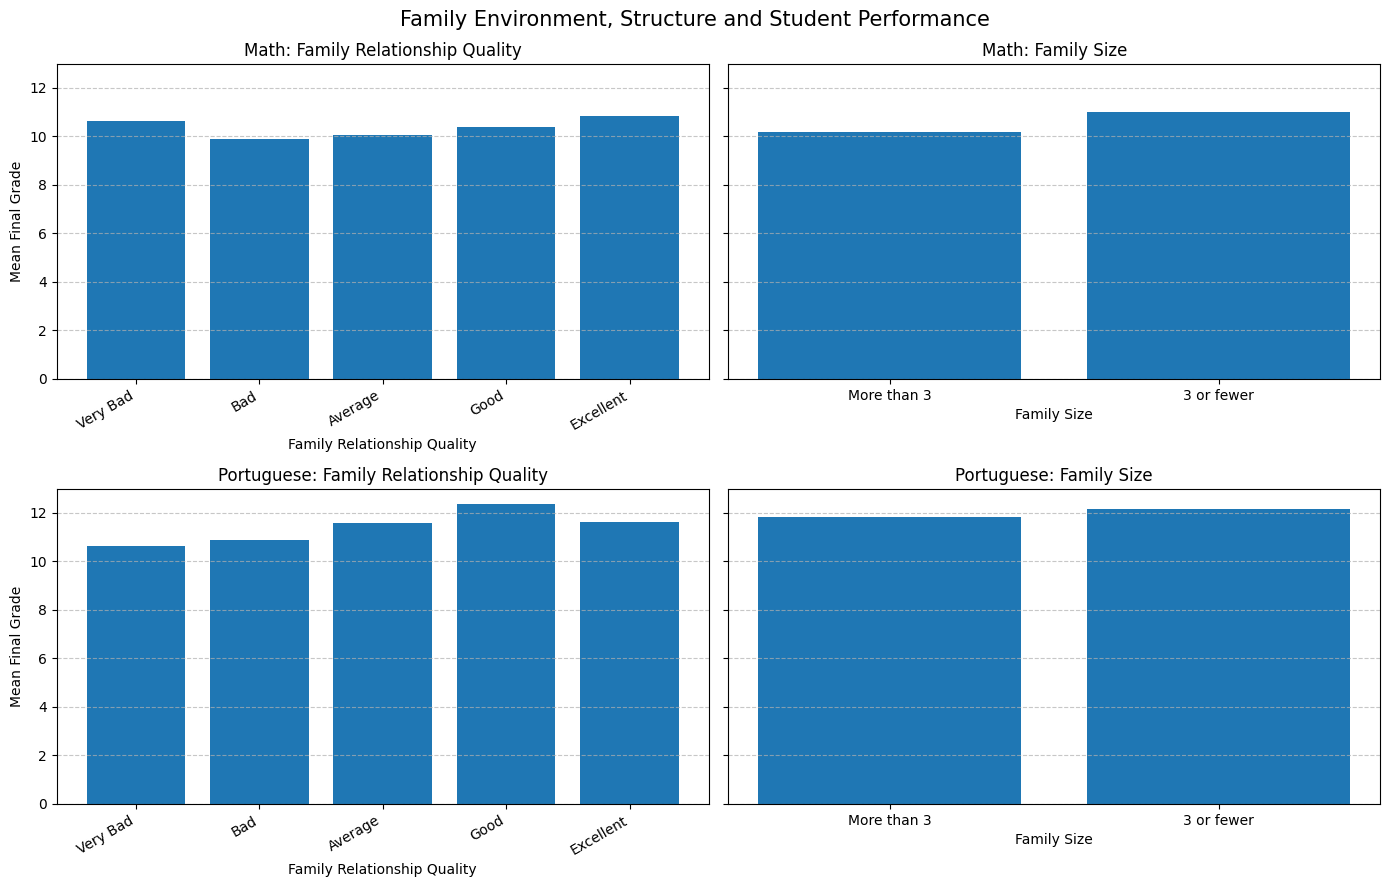

In [49]:
# Family environment/structure and academic performance

# Grouped data
math_famrel = math_df.groupby('famrel')['final_grade'].mean()
port_famrel = port_df.groupby('famrel')['final_grade'].mean()

math_famsize = math_df.groupby('famsize')['final_grade'].mean()
port_famsize = port_df.groupby('famsize')['final_grade'].mean()


# Meaningful labels for family relationship quality
famrel_labels = {
    1: 'Very Bad',
    2: 'Bad',
    3: 'Average',
    4: 'Good',
    5: 'Excellent'
}

# Meaningful labels for family size
famsize_labels = {
    'LE3': '3 or fewer',
    'GT3': 'More than 3'
}


# Create 2 × 2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)


# --------------------------------
# Math — Family Relationship
# --------------------------------
axes[0, 0].bar(
    math_famrel.index,
    math_famrel.values
)

axes[0, 0].set_title('Math: Family Relationship Quality')
axes[0, 0].set_xlabel('Family Relationship Quality')
axes[0, 0].set_ylabel('Mean Final Grade')

axes[0, 0].set_xticks(math_famrel.index)
axes[0, 0].set_xticklabels(
    [famrel_labels[x] for x in math_famrel.index],
    rotation=30,
    ha='right'
)

axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)


# --------------------------------
# Math — Family Size
# --------------------------------
axes[0, 1].bar(
    math_famsize.index,
    math_famsize.values
)

axes[0, 1].set_title('Math: Family Size')
axes[0, 1].set_xlabel('Family Size')

axes[0, 1].set_xticks(math_famsize.index)
axes[0, 1].set_xticklabels(
    [famsize_labels[x] for x in math_famsize.index]
)

axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)


# --------------------------------
# Portuguese — Family Relationship
# --------------------------------
axes[1, 0].bar(
    port_famrel.index,
    port_famrel.values
)

axes[1, 0].set_title('Portuguese: Family Relationship Quality')
axes[1, 0].set_xlabel('Family Relationship Quality')
axes[1, 0].set_ylabel('Mean Final Grade')

axes[1, 0].set_xticks(port_famrel.index)
axes[1, 0].set_xticklabels(
    [famrel_labels[x] for x in port_famrel.index],
    rotation=30,
    ha='right'
)

axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)


# --------------------------------
# Portuguese — Family Size
# --------------------------------
axes[1, 1].bar(
    port_famsize.index,
    port_famsize.values
)

axes[1, 1].set_title('Portuguese: Family Size')
axes[1, 1].set_xlabel('Family Size')

axes[1, 1].set_xticks(port_famsize.index)
axes[1, 1].set_xticklabels(
    [famsize_labels[x] for x in port_famsize.index]
)

axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)


# Overall title
fig.suptitle(
    'Family Environment, Structure and Student Performance',
    fontsize=15
)

plt.tight_layout()
plt.show()

### 6. Which variables have the strongest relationship with final grade?

In [56]:
port_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   school        649 non-null    object
 1   sex           649 non-null    object
 2   age           649 non-null    int64 
 3   address       649 non-null    object
 4   famsize       649 non-null    object
 5   Pstatus       649 non-null    object
 6   Medu          649 non-null    int64 
 7   Fedu          649 non-null    int64 
 8   Mjob          649 non-null    object
 9   Fjob          649 non-null    object
 10  reason        649 non-null    object
 11  guardian      649 non-null    object
 12  traveltime    649 non-null    int64 
 13  studytime     649 non-null    int64 
 14  failures      649 non-null    int64 
 15  schoolsup     649 non-null    object
 16  famsup        649 non-null    object
 17  paid          649 non-null    object
 18  activities    649 non-null    object
 19  nursery 

In [58]:
print("Maths correlation test:")
display(math_df[['age', 'Medu', 'Fedu','traveltime', 'studytime',
       'failures','famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences','first_grade', 'second_grade', 'final_grade']].corr())

print("Portuguese correlation test:")
display(port_df[['age', 'Medu', 'Fedu','traveltime', 'studytime',
       'failures','famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences','first_grade', 'second_grade', 'final_grade']].corr())

Maths correlation test:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,first_grade,second_grade,final_grade
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


Portuguese correlation test:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,first_grade,second_grade,final_grade
age,1.000000,-0.107832,-0.121050,0.034490,-0.008415,0.319968,-0.020559,-0.004910,0.112805,0.134768,0.086357,-0.008750,0.149998,-0.174322,-0.107119,-0.106505
Medu,-0.107832,1.000000,0.647477,-0.265079,0.097006,-0.172210,0.024421,-0.019686,0.009536,-0.007018,-0.019766,0.004614,-0.008577,0.260472,0.264035,0.240151
Fedu,-0.121050,0.647477,1.000000,-0.208288,0.050400,-0.165915,0.020256,0.006841,0.027690,0.000061,0.038445,0.044910,0.029859,0.217501,0.225139,0.211800
traveltime,0.034490,-0.265079,-0.208288,1.000000,-0.063154,0.097730,-0.009521,0.000937,0.057454,0.092824,0.057007,-0.048261,-0.008149,-0.154120,-0.154489,-0.127173
studytime,-0.008415,0.097006,0.050400,-0.063154,1.000000,-0.147441,-0.004127,-0.068829,-0.075442,-0.137585,-0.214925,-0.056433,-0.118389,0.260875,0.240498,0.249789
failures,0.319968,-0.172210,-0.165915,0.097730,-0.147441,1.000000,-0.062645,0.108995,0.045078,0.105949,0.082266,0.035588,0.122779,-0.384210,-0.385782,-0.393316
famrel,-0.020559,0.024421,0.020256,-0.009521,-0.004127,-0.062645,1.000000,0.129216,0.089707,-0.075767,-0.093511,0.109559,-0.089534,0.048795,0.089588,0.063361
freetime,-0.004910,-0.019686,0.006841,0.000937,-0.068829,0.108995,0.129216,1.000000,0.346352,0.109904,0.120244,0.084526,-0.018716,-0.094497,-0.106678,-0.122705
goout,0.112805,0.009536,0.027690,0.057454,-0.075442,0.045078,0.089707,0.346352,1.000000,0.245126,0.388680,-0.015741,0.085374,-0.074053,-0.079469,-0.087641
Dalc,0.134768,-0.007018,0.000061,0.092824,-0.137585,0.105949,-0.075767,0.109904,0.245126,1.000000,0.616561,0.059067,0.172952,-0.195171,-0.189480,-0.204719


**Only first period grade and second period grade variables have strong positive correlations with final grade. The other variables are either weakly positively correlated or weakly negative correlated. Except for 'failures' which s moderately negative correlated with final grade.**
 - failures - number of past class failures (numeric: n if 1<=n<3, else 4)


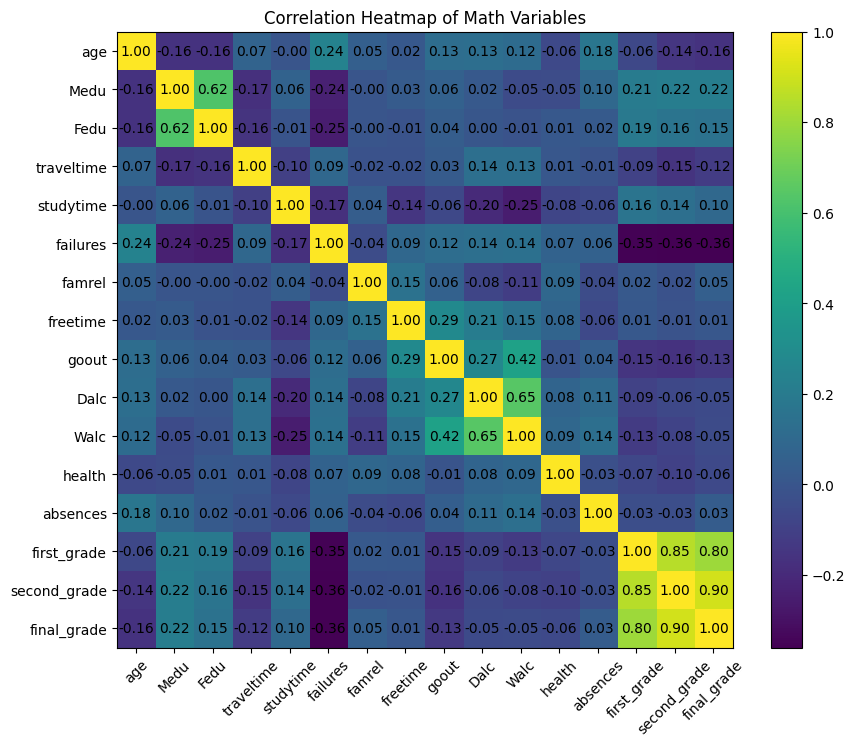

In [61]:
# correlation heatmap
correlation_matrix = math_df[['age', 'Medu', 'Fedu','traveltime', 'studytime',
       'failures','famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences','first_grade', 'second_grade', 'final_grade']].corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    list(correlation_matrix.columns),
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    list(correlation_matrix.columns)
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap of Math Variables')

plt.show()

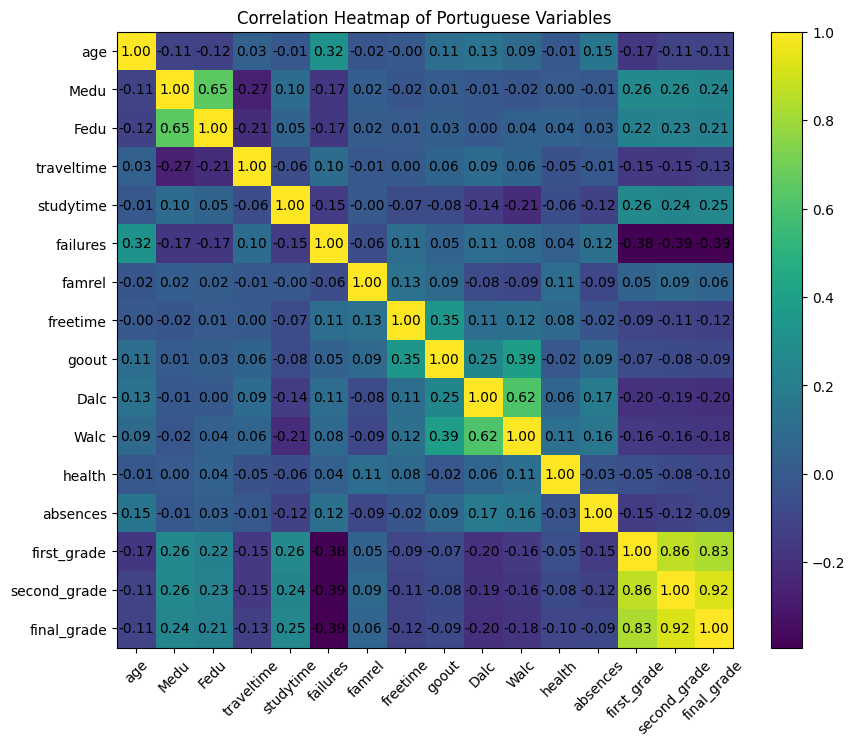

In [62]:
# correlation heatmap
correlation_matrix = port_df[['age', 'Medu', 'Fedu','traveltime', 'studytime',
       'failures','famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences','first_grade', 'second_grade', 'final_grade']].corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    list(correlation_matrix.columns),
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    list(correlation_matrix.columns)
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap of Portuguese Variables')

plt.show()